In [2]:
import os

from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [13]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

api_arxiv = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=1000)

arxiv=ArxivQueryRun(api_wrapper=api_arxiv)

arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a series of feed-forward layers applied over the patch and feature dimensions in an alternating fashion. In experiments on ImageNet, this architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains 74.9\\% top-1 accuracy, compared to 77.9\\% and 79.9\\% for ViT and DeiT respectively. These results indicate that aspects

In [19]:
api_wiki=WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)

wiki=WikipediaQueryRun(api_wrapper=api_wiki)
wiki.invoke("Artificial Intelligence")

'Page: Artificial intelligence\nSummary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.\nHigh-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely availabe to generate image, audio, and videos from text prompts.\nThe traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support fo

In [3]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [20]:
tavily=TavilySearchResults()

In [5]:
tavily.invoke("provide me the latest developmets in the field of AI")

[{'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Source: China Daily\n\n### Disney Integrates Generative AI into Core Operating Model\n\nDate: December 24, 2025\n\nSummary: The Walt Disney Company has officially begun embedding generative AI across its entire operating structure, moving beyond experimental projects to fundamental business integration. The initiative aims to enhance efficiency in content creation, post-production, and personalized guest experiences within its theme parks. By centralizing AI development, Disney hopes to streamline creative workflows and leverage its massive library of intellectual property to train proprietary models while maintaining strict control over brand integrity and copyright.\n\nSource: AI News ↗\n\n### AI Bubble Hits Salesforce: Executives Acknowledge Trust Issues, Scale Back AI After Major Layoffs [...] Date: December 2, 2025 Summary: Fuj

In [38]:
## combine all tools in a list 

tools=[tavily,arxiv,wiki]



In [39]:
## initialize llm model

from langchain_groq import ChatGroq

In [40]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [41]:
llm_with_tools=llm.bind_tools(tools)

In [42]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage

llm_with_tools.invoke([HumanMessage(content = f"what are the latest developments in the field of AI?")]).tool_calls


[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest developments in AI'},
  'id': 'c448603vb',
  'type': 'tool_call'}]

In [43]:
tools

[TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=1000)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/Users/ADML/Desktop/lg/.venv/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=1000))]

In [44]:
## chat bot with langgraph 

from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    


In [45]:
from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [46]:
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

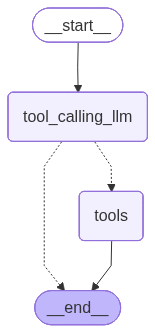

In [47]:
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)

builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
     tools_condition
    
)

builder.add_edge("tools",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [48]:
mess=graph.invoke({"messages":[HumanMessage(content = "attention is all you need paper summary?")]})

for m in mess["messages"]:
   m.pretty_print()

================================ Human Message =================================

attention is all you need paper summary?
================================== Ai Message ==================================
Tool Calls:
  arxiv (38xgrgkzz)
 Call ID: 38xgrgkzz
  Args:
    query: Attention Is All You Need paper summary
================================= Tool Message =================================
Name: arxiv

Published: 2006-01-22
Title: This paper has been withdrawn
Authors: This paper has been withdrawn
Summary: This paper has been withdrawn

Published: 2025-12-03
Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Authors: Anton Alyakin
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponential growth ($R^2$ > 0.994

In [49]:
mess=graph.invoke({"messages":[HumanMessage(content = "recent spat between YC and OpenAI?")]})

for m in mess["messages"]:
   m.pretty_print()

================================ Human Message =================================

recent spat between YC and OpenAI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ygpegt3z7)
 Call ID: ygpegt3z7
  Args:
    query: YC OpenAI recent spat
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "I edited my comment to clarify what I meant. The start was him ...", "url": "https://news.ycombinator.com/item?id=38375722", "content": "| |  |  |  |  ---  |  |  | 6gvONxR4sf7o on Nov 22, 2023  | parent | context | favorite | on: We have reached an agreement in principle for Sam ...   I edited my comment to clarify what I meant. The start was him pushing to move fast and break things in the classic YC kind of way. And it's BS to say that she didn't speak to the CEO or try to affect change first. The safety camp inside openai has been unsuccessfully trying

In [51]:
mess=graph.invoke({"messages":[HumanMessage(content = "what is machine learning")]})

for m in mess["messages"]:
   m.pretty_print()

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (8enpf0mft)
 Call ID: 8enpf0mft
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation (mathematical programming) methods compose the foundations of mac